In [1]:
%load_ext autoreload
%autoreload 2
import time
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
from estimation_fct_v2 import *
from graph_format import *

# Load model
from model_inflexible import ModelClass

model = ModelClass() 

par = model.par
sol = model.sol
sim = model.sim


In [2]:
_, _, moments = prepare_data(par)

In [3]:
means_string = "Data ny def/mean_matrix.csv"
covariance_string = "Data ny def/variance_matrix.csv"

variables = ["extensive_v2"]

mean, variance_diag = load_and_process_data(means_string, covariance_string, par, variables)

variance_cut = np.concatenate([
    variance_diag[:40],
    # variance_diag[55:55+70],
    # variance_diag[55+70:55+70+40]
])

diag_inv = 1 / variance_cut
weight = np.diag(diag_inv)

In [4]:
theta_names = ("chi_base", "chi_total")

theta_final = np.array([90528, 169704])

for i, name in enumerate(theta_names):
    if name == "retirement_age" or name == "retirement_age" or name == "first_retirement":
        setattr(model.par, name, int(theta_final[i]))
    
    else:
        setattr(model.par, name, theta_final[i])


In [9]:
def randomize_theta_init(theta_init, bounds, pct=0.05):
    randomized = []
    for val, (lower, upper) in zip(theta_init, bounds):
        delta = pct * val
        min_val = max(lower, val - delta)
        max_val = min(upper, val + delta)
        randomized_val = np.random.uniform(min_val, max_val)
        randomized.append(randomized_val)
    return np.array(randomized)

# Prepare SMM
# theta_names = ("sigma", "gamma", "mu", "zeta", "gamma_1", "gamma_2")

# theta_init = np.array([1.1324159182, 0.6371231124, 6.5, 2.8582779690, 0.1812484876, 4.8808529427])

theta_names = ("gamma_1", "gamma_2")

theta_init = np.array([0.1076340900, 2.7220855882])

# Original bounds
# orig_bounds = [(0.1, 6.0),   # sigma
#                (0.1, 10.0),  # gamma
#                (0.0, 20.0),  # mu
#                (0.0, 15.0),  # zeta
#                (0.0, 0.3),  # gamma_1
#                (0.01, 10.0)   # gamma_2
#                ] 

               # Original bounds
orig_bounds = [
               (0.0, 0.3),  # gamma_1
               (0.01, 10.0)   # gamma_2
               ] 

theta_init_scaled = scale_params(theta_init, orig_bounds)

theta_random = randomize_theta_init(theta_init, orig_bounds)
theta_random_scaled = scale_params(theta_random, orig_bounds)

# Do SMM
objective = lambda theta: obj_func(theta, theta_names, mean, weight, model, orig_bounds, do_print=True)

res = minimize(
    objective, 
    theta_init_scaled,
    method='nelder-mead',
    bounds=[(0,1)] * len(theta_init_scaled),
    tol=1e-6,
    options={"maxiter":2000}
)

theta_final = unscale_params(res.x, orig_bounds)

print(theta_final)

0.1076340900, 2.7220855882, 
Error = 0.42569, Time = 30.8 seconds
0.1130157945, 2.7220855882, 
Error = 0.49333, Time = 30.7 seconds
0.1076340900, 2.8576898676, 
Error = 0.41976, Time = 30.8 seconds
0.1022523855, 2.8576898676, 
Error = 0.37387, Time = 30.7 seconds
0.0968706810, 2.9254920073, 
Error = 0.36368, Time = 30.5 seconds
0.0968706810, 3.0610962867, 
Error = 0.36309, Time = 30.6 seconds
0.0914889765, 3.2306016360, 
Error = 0.39716, Time = 30.5 seconds
0.0861072720, 3.1288984264, 
Error = 0.47298, Time = 30.7 seconds
0.1022523855, 2.9254920073, 
Error = 0.37143, Time = 30.6 seconds
0.0914889765, 3.0610962867, 
Error = 0.39309, Time = 30.9 seconds
0.0995615332, 2.9593930772, 
Error = 0.36171, Time = 31.5 seconds
0.0995615332, 3.0949973566, 
Error = 0.36007, Time = 30.6 seconds
0.1009069594, 3.1797500312, 
Error = 0.36218, Time = 30.5 seconds
0.1022523855, 2.9932941470, 
Error = 0.36883, Time = 30.5 seconds
0.0982161071, 3.0441457518, 
Error = 0.36060, Time = 30.8 seconds
0.09821610

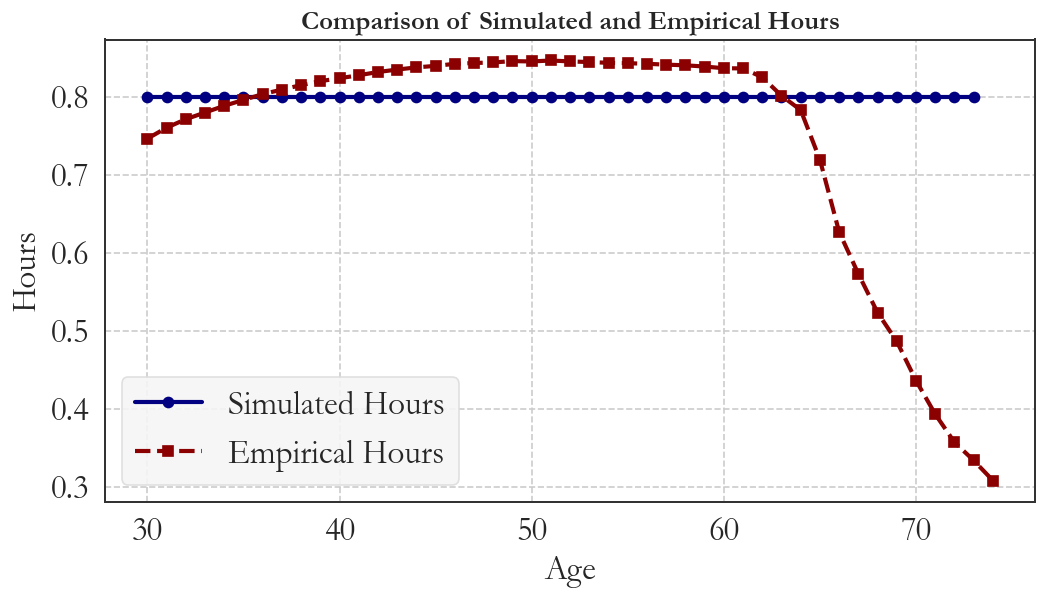

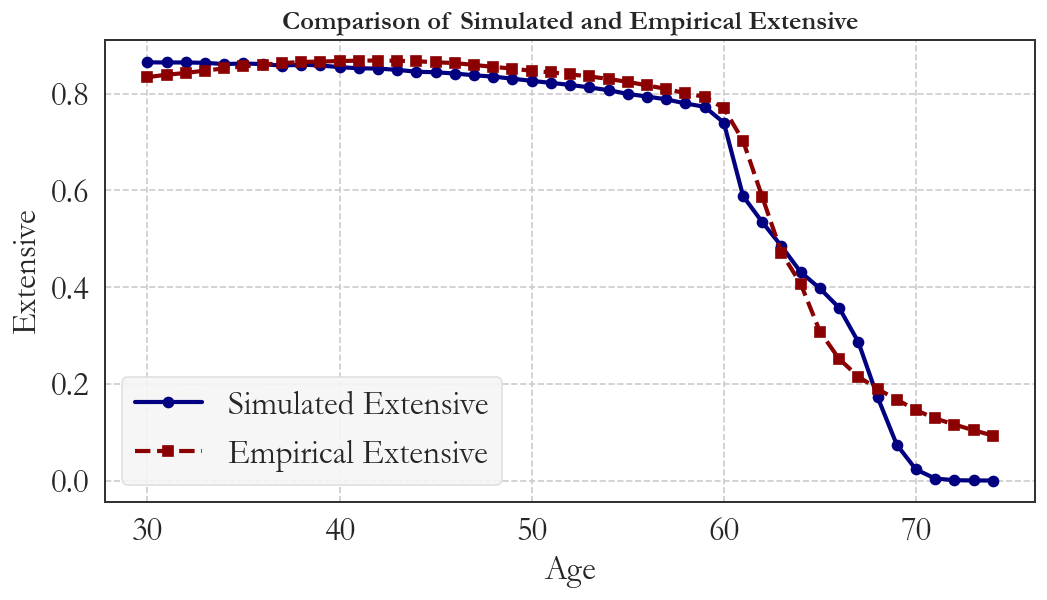

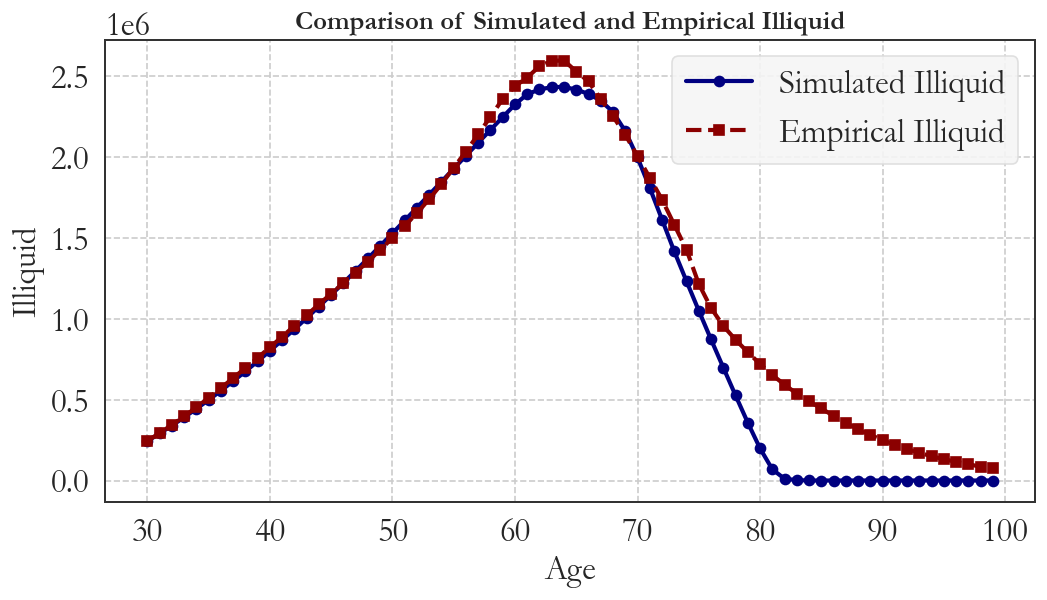

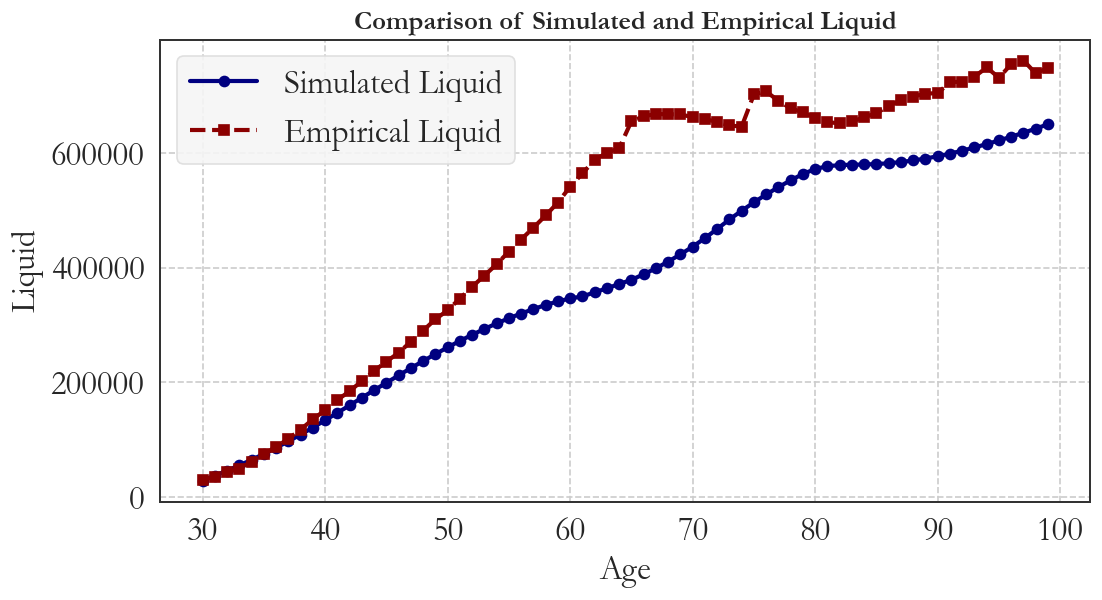

In [12]:
# theta_names = ("chi_base", "chi_total")
# # # theta_final = unscale_params(res.x, orig_bounds)
# # # theta_final = theta_init

# theta_final = np.array([90528, 169704])

# for i, name in enumerate(theta_names):
#     if name == "retirement_age" or name == "retirement_age" or name == "first_retirement":
#         setattr(model.par, name, int(theta_final[i]))
    
#     else:
#         setattr(model.par, name, theta_final[i])



# Load the model with calibrated values
theta_names = ("gamma_1", "gamma_2")
# # theta_names = ("beta", "zeta")

# theta_final = unscale_params(res.x, orig_bounds)

theta_final = np.array([0.09884474, 3.25370956])

for i, name in enumerate(theta_names):
    setattr(model.par, name, theta_final[i])


model.solve()
model.simulate()

# plot the graph with calibrated values 
a_dict = {
    'hours': [np.nanmean(np.where(model.sim.ex == 1, model.sim.h, np.nan),axis=0)[:45], moments['hours']],
    'extensive': [np.mean(model.sim.ex, axis=0)[:45], moments['extensive']],
    'illiquid': [np.clip(np.mean(model.sim.s, axis=0), 0, None), moments['savings']],
    'liquid': [np.mean(model.sim.a, axis=0), moments['assets']]
}

# Define colors
simulated_color = "navy"  # Dark blue
empirical_color = "darkred"  # Dark red
ci_color = "lightcoral"  # Light red for confidence bands

for key, (simulated, empirical) in a_dict.items():
    plt.figure(figsize=(10, 5))
    
    x_vals = np.arange(len(empirical)) + par.start_age
    
    plt.plot(x_vals, simulated, label=f"Simulated {key.capitalize()}", marker="o", color=simulated_color)
    plt.plot(x_vals, empirical, label=f"Empirical {key.capitalize()}", linestyle="--", marker="s", color=empirical_color)

    # # 99.9% confidence interval
    # ci = std_dev
    # plt.fill_between(x_vals, empirical - ci, empirical + ci, color=ci_color, alpha=0.4, label="Empirical Standard Deviation")

    plt.xlabel("Age")
    plt.ylabel(key.capitalize())
    plt.title(f"Comparison of Simulated and Empirical {key.capitalize()}")
    plt.legend()
    plt.grid(True)
    plt.show()


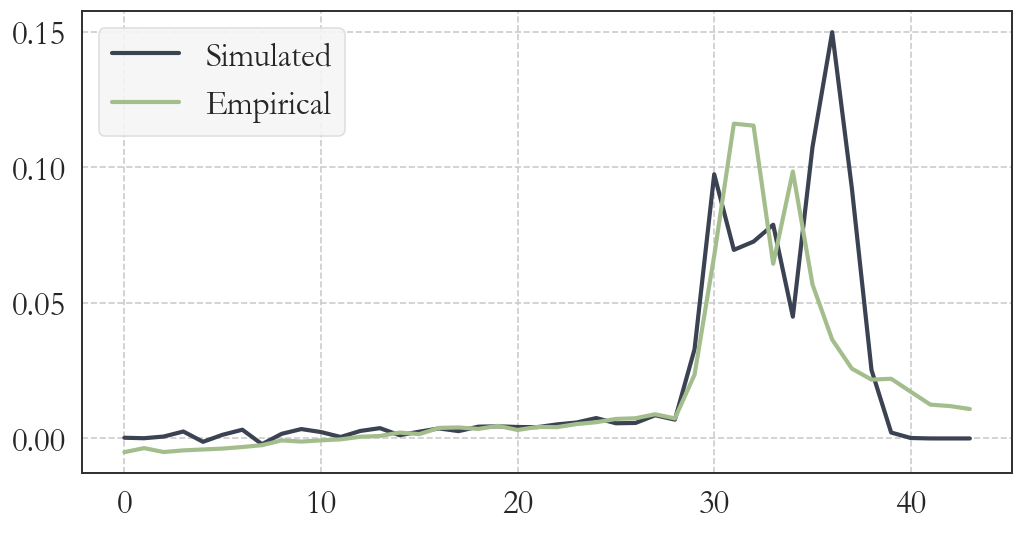

In [7]:
#take first differences of this np.mean(model.sim.ex, axis=0)[:45]

diff_ex_sim = -np.diff(np.mean(model.sim.ex, axis=0)[:45], axis=0)
diff_ex_moments = -np.diff(moments['extensive'][:45], axis=0)
plt.plot(diff_ex_sim, label='Simulated')
plt.plot(diff_ex_moments, label='Empirical')
plt.legend()
plt.show()

## Replacement rates

(0.0, 250000.0)

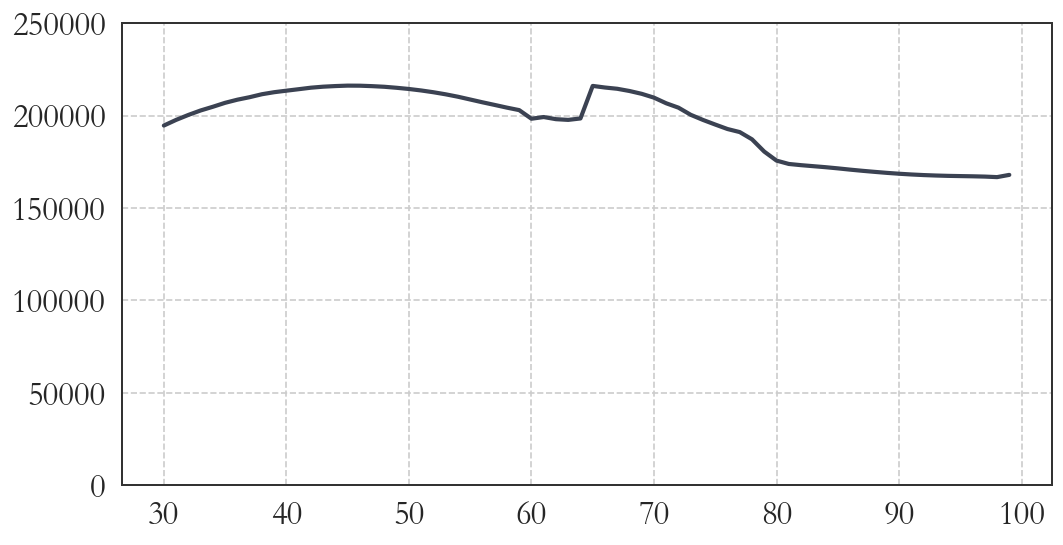

In [8]:
mask = model.sim.a > 0
c_filtered_mean = np.nanmean(np.where(mask, model.sim.c, np.nan), axis=0)

plt.plot(x_vals, c_filtered_mean, label='Simulated Consumption')
plt.ylim(0, 250000)

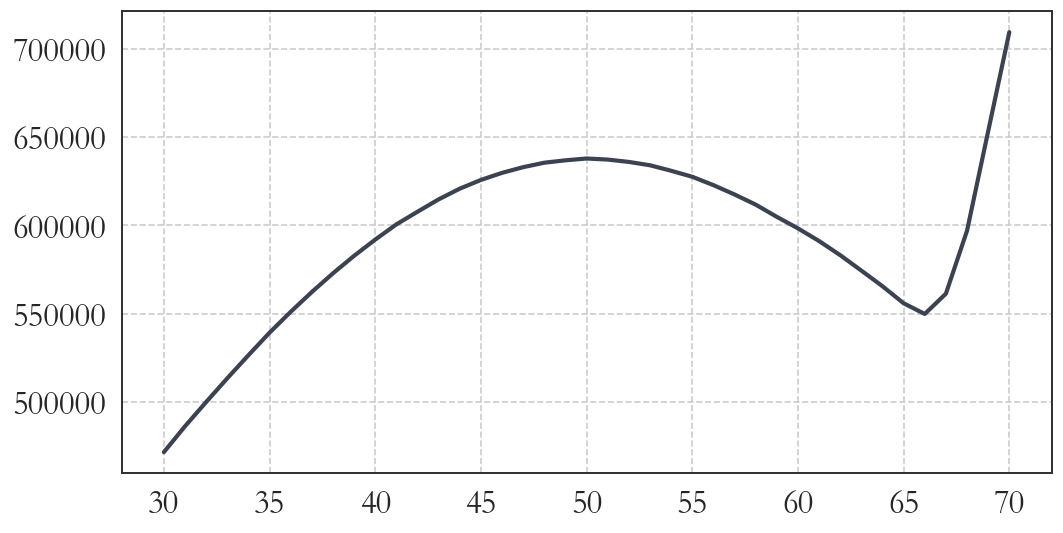

In [15]:
mask = model.sim.ex == 1
c_filtered_mean = np.nanmean(np.where(mask, model.sim.w, np.nan), axis=0)

plt.plot(x_vals, c_filtered_mean, label='Simulated Consumption')
# plt.ylim(0, 250000)

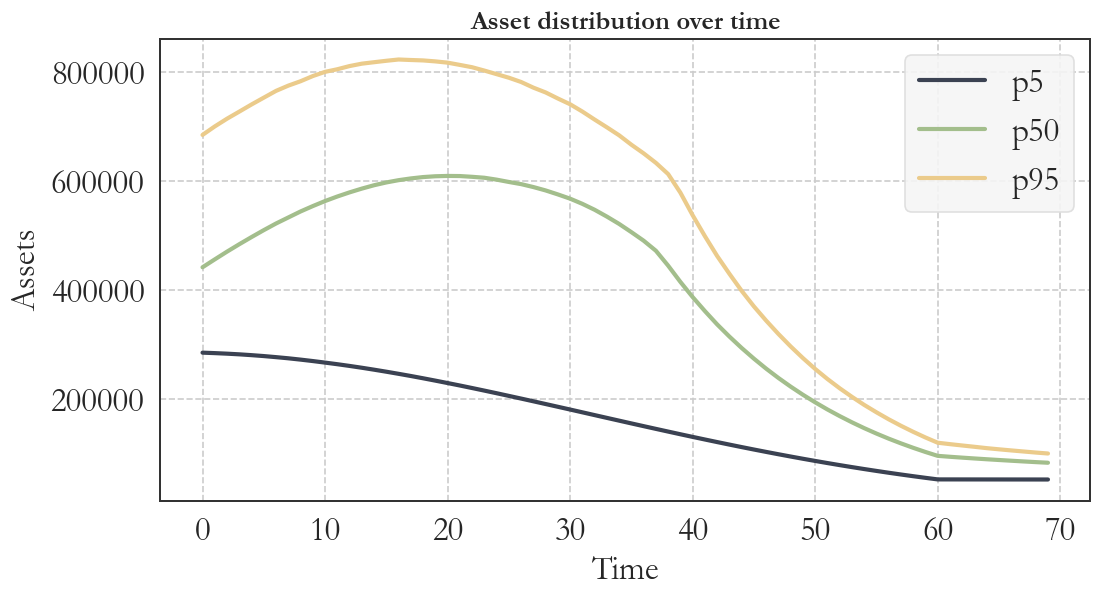

In [16]:
import numpy as np

w = model.sim.w
p5_w = np.percentile(w, 5, axis=0)
p50_w = np.percentile(w, 50, axis=0)
p95_w = np.percentile(w, 95, axis=0)

plt.figure()
plt.plot(p5_w, label='p5')
plt.plot(p50_w, label='p50')
plt.plot(p95_w, label='p95')
plt.xlabel('Time')
plt.ylabel('Assets')
plt.title('Asset distribution over time')
plt.legend()
plt.show()

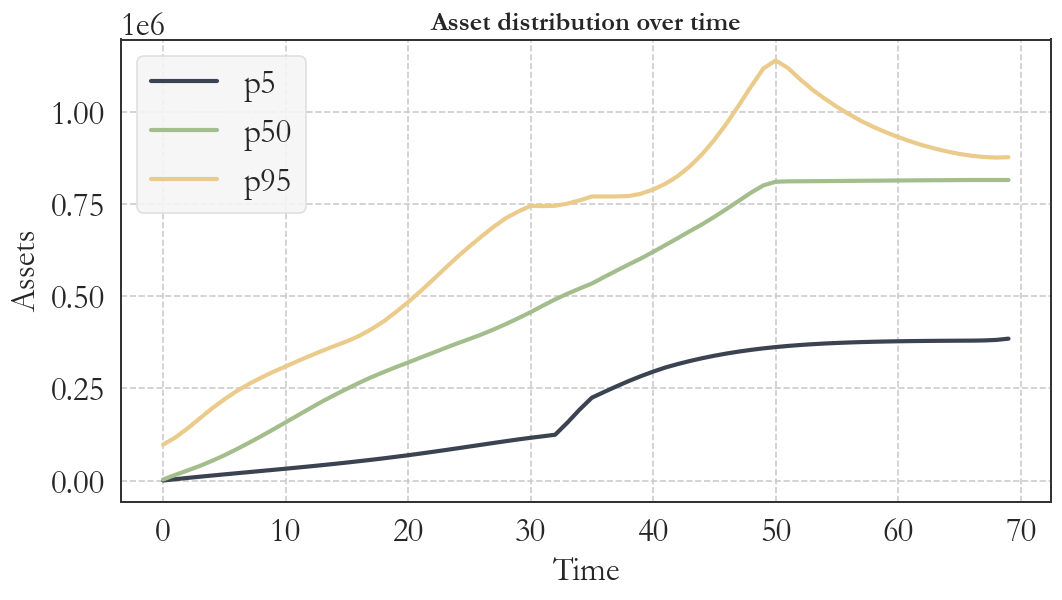

In [17]:
import numpy as np

a = model.sim.a
p5 = np.percentile(a, 5, axis=0)
p50 = np.percentile(a, 50, axis=0)
p95 = np.percentile(a, 95, axis=0)

plt.figure()
plt.plot(p5, label='p5')
plt.plot(p50, label='p50')
plt.plot(p95, label='p95')
plt.xlabel('Time')
plt.ylabel('Assets')
plt.title('Asset distribution over time')
plt.legend()
plt.show()

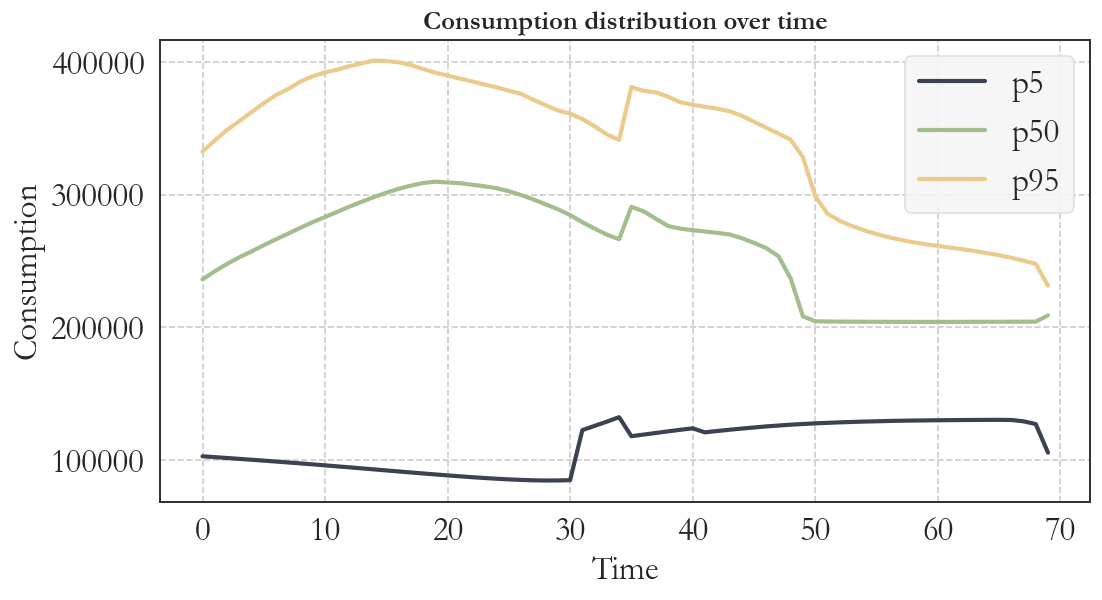

In [18]:
import numpy as np

c = model.sim.c
p5_c  = np.percentile(c, 5, axis=0)
p50_c = np.percentile(c, 50, axis=0)
p95_c = np.percentile(c, 95, axis=0)

plt.figure()
plt.plot(p5_c, label='p5')
plt.plot(p50_c, label='p50')
plt.plot(p95_c, label='p95')
plt.xlabel('Time')
plt.ylabel('Consumption')
plt.title('Consumption distribution over time')
plt.legend()
plt.show()

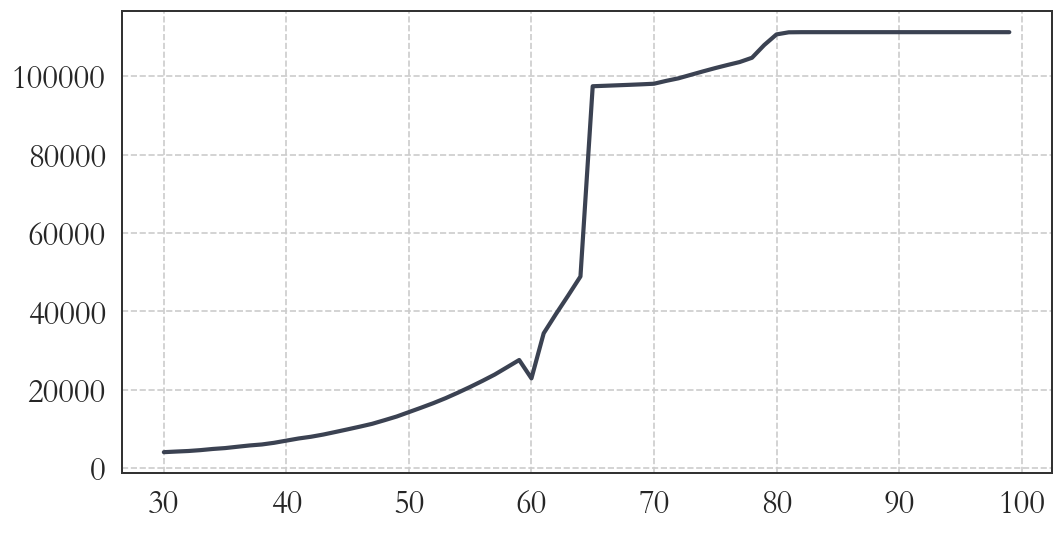

In [19]:
plt.plot(x_vals, model.sim.chi_payment.mean(axis=0), label='Simulated Chi Payment') 

In [20]:
pre_retirement_income = np.nanmean(np.where(model.sim.ex == 1, model.sim.income, np.nan))
post_retirement_income = np.nanmean(np.where(model.sim.ex == 0, model.sim.income, np.nan))  

replacement_rate = post_retirement_income / pre_retirement_income
print(f"Replacement Rate: {replacement_rate:.2f}")

Replacement Rate: 0.65


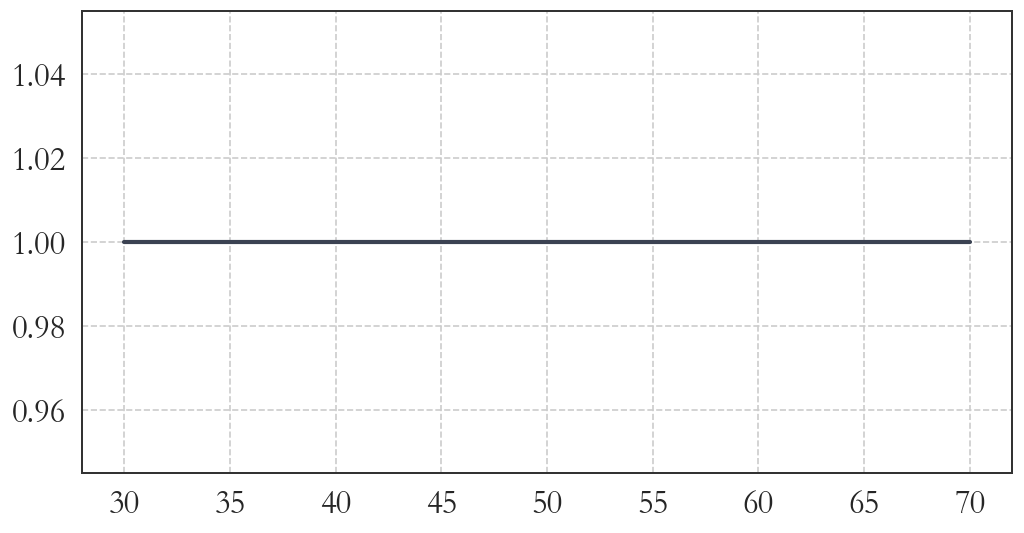

In [21]:
plt.plot(
    x_vals,
    np.nanmean(
        np.where(model.sim.ex == 1, model.sim.h, np.nan),
        axis=0
    ),
    label='Simulated Income'
)

In [22]:
# prepare your data dict
a_dict = {
    'hours': [np.nanmean(np.where(model.sim.ex == 1, model.sim.h, np.nan), axis=0)[:55],
              moments['hours']],
    'extensive': [np.mean(model.sim.ex, axis=0)[:55],
                  moments['extensive']],
    'liquid': [np.mean(model.sim.a, axis=0),
               moments['assets']]
}


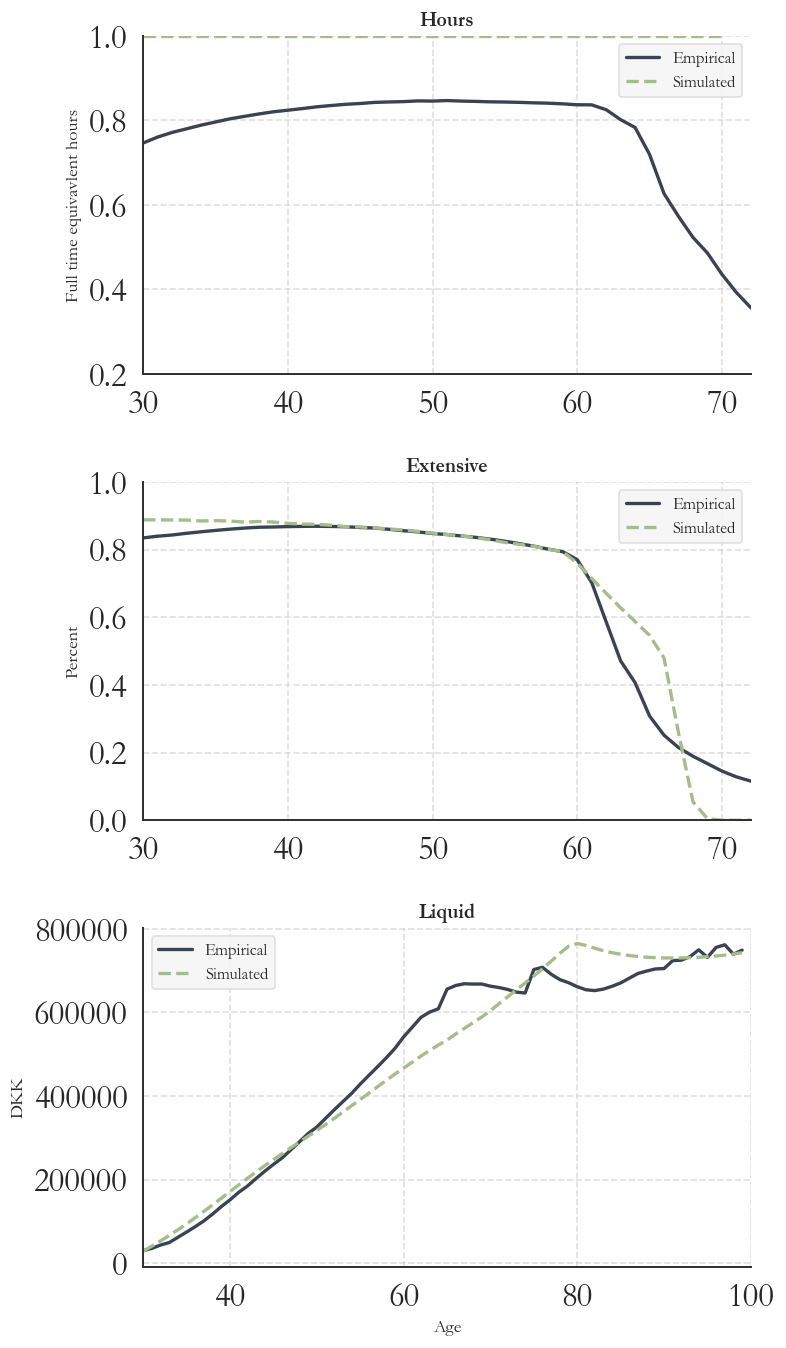

In [23]:
plot_model_vs_data_grid(a_dict, title="", save_title="in_sample_fit.png")


In [13]:
means_data = pd.read_csv("Data/mean_matrix.csv")

b_dict = {
    'illiquid': [np.clip(np.clip(np.mean(model.sim.s, axis=0), 0, None) / 1_000_000, 0, None),
                 moments['savings'] / 1_000_000]  ,
    'wages':    [np.nanmean(np.where(model.sim.ex==1, model.sim.w, np.nan)[:, :40] , axis=0),
                 means_data[means_data["alder"] <= 60]["hourly_salary_plsats_Mean"].to_numpy() * 1924]
        }

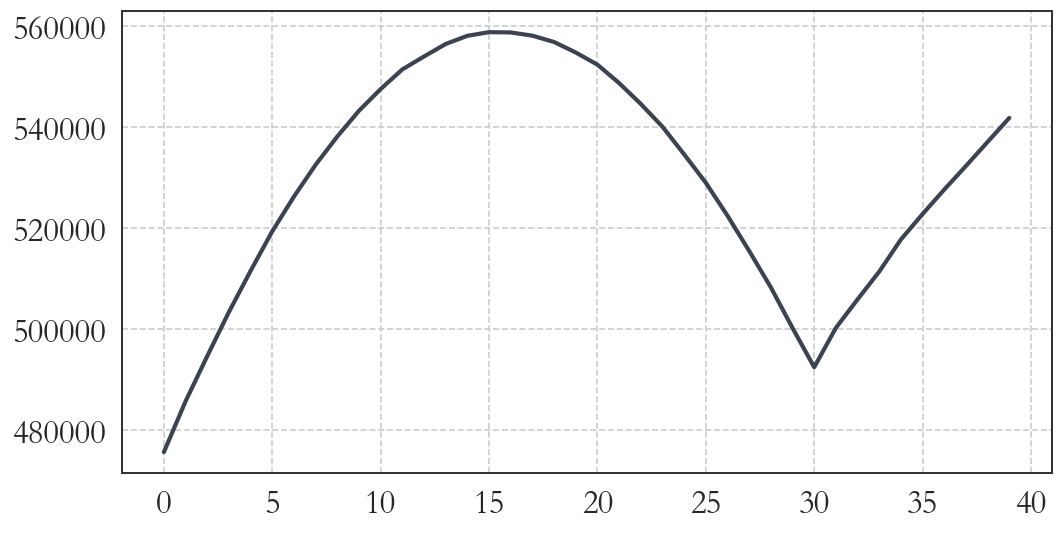

In [6]:
plt.plot(np.nanmean(np.where(model.sim.ex==1, model.sim.w, np.nan)[:, :40] , axis=0))

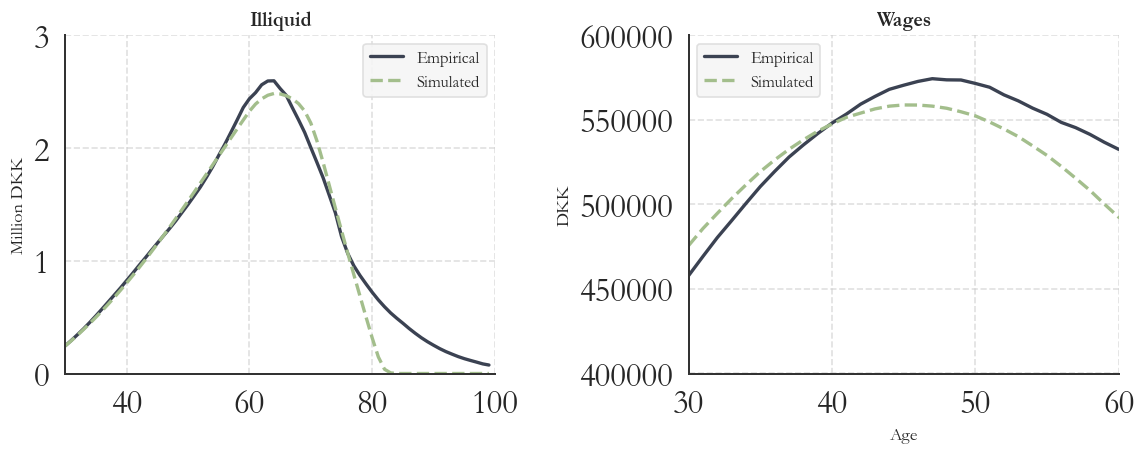

In [14]:
plot_model_vs_data_grid_oos(b_dict, title="", save_title="out_of_sample_fit.png")


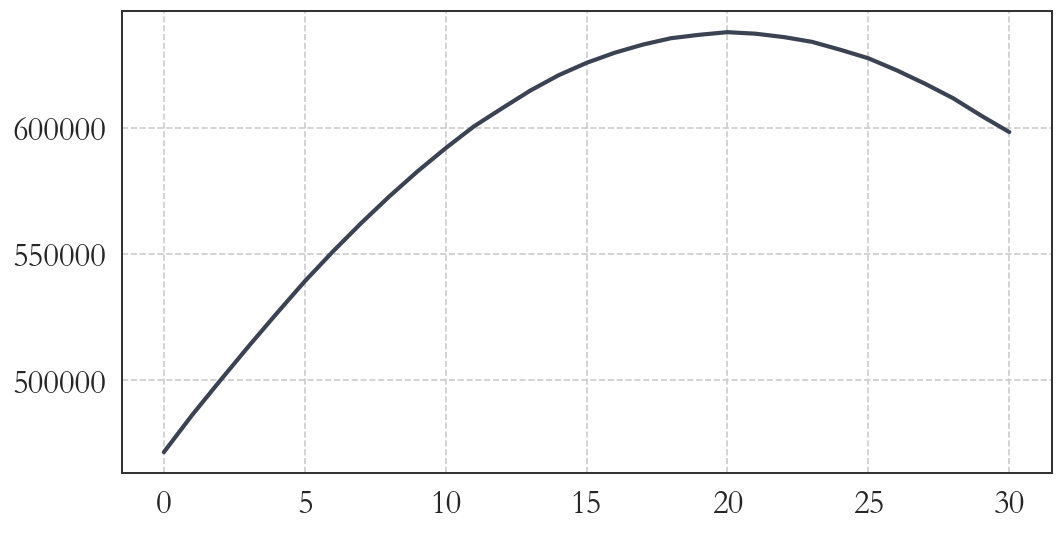

In [28]:
plt.plot(np.nanmean(np.where(model.sim.ex==1, model.sim.w, np.nan)[:, :31] , axis=0))